In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# =========================================================
# 1. SAFE LOADER
# =========================================================
def load_and_validate_csv(path, required_cols=None):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=True)

    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print(f"[WARNING] {path} missing columns: {missing}")
    return df


In [ ]:
# =========================================================
# 2. METRICS
# =========================================================
def eval_metrics(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    smape = 100 * np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred)))
    wmape = 100 * np.sum(np.abs(actual - pred)) / np.sum(actual)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "wMAPE": wmape}

In [ ]:
# =========================================================
# 3. LSTM HELPERS
# =========================================================
def create_sequences(X, y, look_back=14):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i+look_back)])
        ys.append(y[i+look_back])
    return np.array(Xs), np.array(ys)

def run_lstm(daily, look_back=14):
    features = daily.drop(columns=["ds", "y"]).values
    target = daily["y"].values.reshape(-1, 1)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, look_back=look_back)

    split = int(0.8 * len(X_seq))
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    model_lstm = Sequential([
        LSTM(64, activation="relu", return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
        Dropout(0.2),
        LSTM(32, activation="relu"),
        Dropout(0.2),
        Dense(1)
    ])

    model_lstm.compile(optimizer="adam", loss="mse")
    model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    y_pred_scaled = model_lstm.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_rescaled = scaler_y.inverse_transform(y_test)

    # Build aligned dataframe
    dates_test = daily["ds"].iloc[-len(y_test_rescaled):].reset_index(drop=True)
    df_lstm = pd.DataFrame({"ds": dates_test, "y": y_test_rescaled.flatten(), "yhat": y_pred.flatten()})

    # Weekly
    weekly_actual = df_lstm.resample("W-MON", on="ds").sum().reset_index()
    weekly_forecast = df_lstm.resample("W-MON", on="ds").sum().reset_index()

    daily_metrics = eval_metrics(df_lstm["y"], df_lstm["yhat"])
    weekly_metrics = eval_metrics(weekly_actual["y"], weekly_forecast["yhat"])

    return df_lstm, daily_metrics, weekly_metrics


In [ ]:
# =========================================================
# 4. FULL PIPELINE (Prophet + LSTM)
# =========================================================
def run_pipeline(enhanced_path, predicted_path):
    # Load
    df = load_and_validate_csv(enhanced_path)
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

    # Daily aggregation
    daily = (
        df.groupby("event_date")
          .agg({
              "item_revenue": "sum",
              "discount_percent": "mean",
              "user_product_view_count": "sum",
              "user_product_purchase_count": "sum",
              "campaign_type": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
              "channel": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
          })
          .reset_index()
    )

    daily = pd.get_dummies(daily, columns=["campaign_type", "channel"], drop_first=True)
    daily.rename(columns={"event_date": "ds", "item_revenue": "y"}, inplace=True)

    # ---------------- Prophet ----------------
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    for col in daily.columns:
        if col not in ["ds", "y"]:
            model.add_regressor(col)

    model.fit(daily)

    future = model.make_future_dataframe(periods=14)
    future = future.merge(daily.drop(columns="y"), on="ds", how="left")
    future.fillna(method="ffill", inplace=True)

    forecast = model.predict(future)
    merged = pd.merge(daily[["ds", "y"]], forecast[["ds", "yhat"]], on="ds", how="left")

    # Weekly Prophet
    weekly_actual = daily.resample("W-MON", on="ds").sum().reset_index()
    weekly_forecast = forecast[["ds", "yhat"]].resample("W-MON", on="ds").sum().reset_index()

    prophet_daily_metrics = eval_metrics(merged["y"], merged["yhat"])
    prophet_weekly_metrics = eval_metrics(weekly_actual["y"], weekly_forecast["yhat"])

    # ---------------- LSTM ----------------
    df_lstm, lstm_daily_metrics, lstm_weekly_metrics = run_lstm(daily)

    # ---------------- Plots ----------------
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Daily
    axes[0].plot(merged["ds"], merged["y"], label="Actual GMV", marker="o")
    axes[0].plot(merged["ds"], merged["yhat"], label="Prophet Forecast", marker="x")
    axes[0].plot(df_lstm["ds"], df_lstm["yhat"], label="LSTM Forecast", marker="s")
    axes[0].set_title("Daily GMV Forecast Comparison")
    axes[0].legend()

    # Weekly
    axes[1].plot(weekly_actual["ds"], weekly_actual["y"], label="Weekly Actual", marker="o")
    axes[1].plot(weekly_forecast["ds"], weekly_forecast["yhat"], label="Prophet Weekly Forecast", marker="x")
    axes[1].plot(df_lstm.resample("W-MON", on="ds").sum().reset_index()["ds"],
                 df_lstm.resample("W-MON", on="ds").sum().reset_index()["yhat"],
                 label="LSTM Weekly Forecast", marker="s")
    axes[1].set_title("Weekly GMV Forecast Comparison")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "Prophet_Daily": prophet_daily_metrics,
        "Prophet_Weekly": prophet_weekly_metrics,
        "LSTM_Daily": lstm_daily_metrics,
        "LSTM_Weekly": lstm_weekly_metrics
    }

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmphnboo_an/_fjf9c6m.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmphnboo_an/vu94mayi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37760', 'data', 'file=/tmp/tmphnboo_an/_fjf9c6m.json', 'init=/tmp/tmphnboo_an/vu94mayi.json', 'output', 'file=/tmp/tmphnboo_an/prophet_modelismo1pan/prophet_model-20250923171350.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
17:13:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:13:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/tmp/ipython-input-2332801822.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use ob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


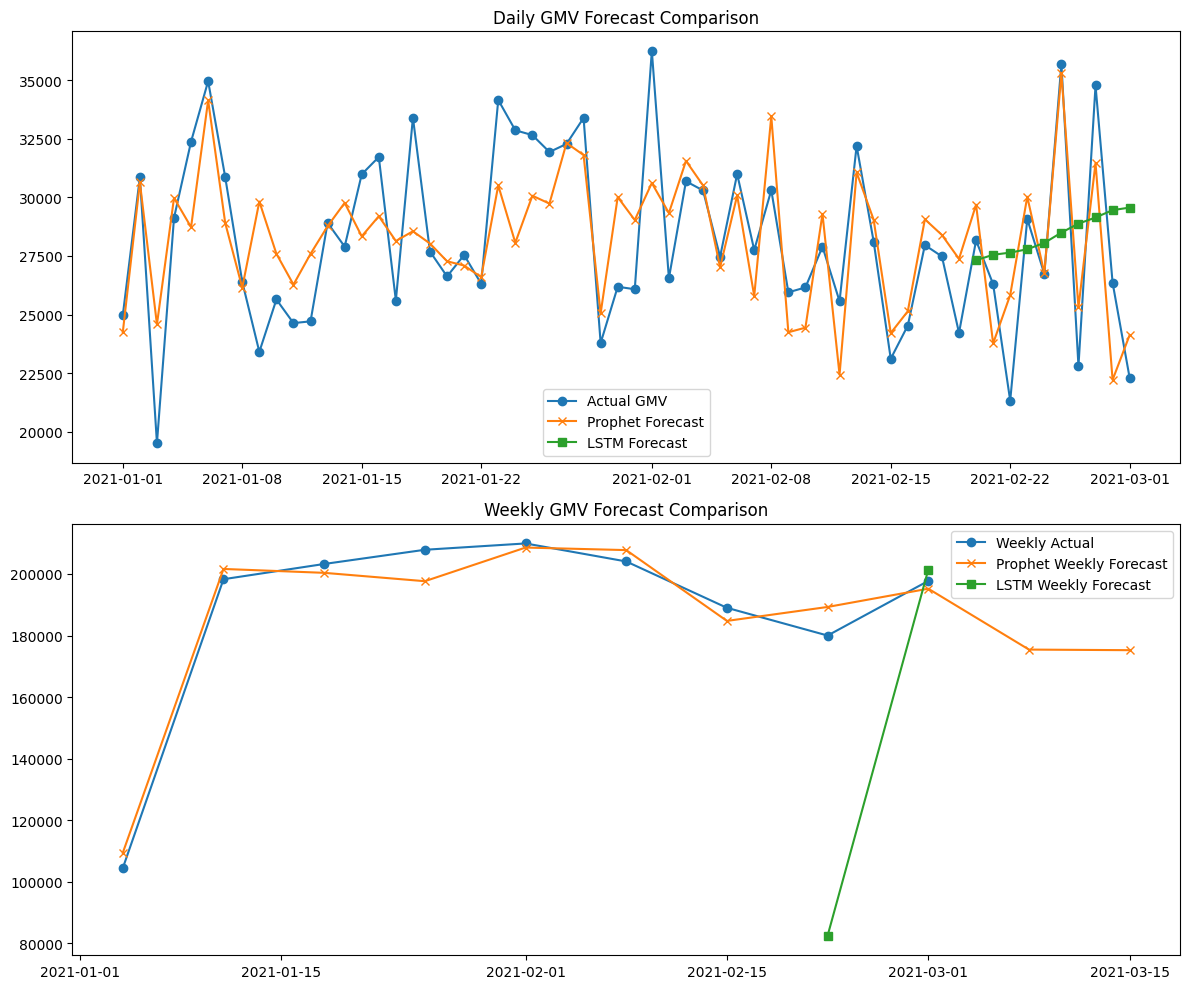


📊 Forecast Results Comparison:

Prophet_Daily:
   MAE  = 2002.72
   RMSE = 2515.86
   MAPE = 7.31
   SMAPE= 7.23
   wMAPE= 7.09

Prophet_Weekly:
   MAE  = 4720.12
   RMSE = 5521.44
   MAPE = 2.66
   SMAPE= 2.64
   wMAPE= 2.51

LSTM_Daily:
   MAE  = 4028.14
   RMSE = 4777.13
   MAPE = 15.41
   SMAPE= 14.55
   wMAPE= 14.73

LSTM_Weekly:
   MAE  = 5187.40
   RMSE = 5410.45
   MAPE = 5.36
   SMAPE= 5.16
   wMAPE= 3.79


In [ ]:
# =========================================================
# 5. RUN MAIN
# =========================================================
if __name__ == "__main__":
    results = run_pipeline(
        enhanced_path="enhanced_synthetic_discount_dataset.csv",
        predicted_path="predicted_conversions.csv",
    )
    print("\n📊 Forecast Results Comparison:")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        for k, v in metrics.items():
            print(f"   {k:<5}= {v:.2f}")